In [ ]:
'''Question 1 :
An airline tracks flight delays (in minutes) for 20 flights. Analyze the flight delays to calculate percentiles, detect outliers, and evaluate the overall distribution.
DataSet:
delays = [15, 30, 45, 20, 25, 100, 5, 60, 35, 50, 
          120, 80, 10, 75, 90, 200, 55, 40, 70, 150]'''

In [9]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

data = [15, 30, 45, 20, 25, 100, 5, 60, 35, 50, 
          120, 80, 10, 75, 90, 200, 55, 40, 70, 150]

###percentile & Outliers calculation:
Q1=np.percentile(data, 25)
Q3=np.percentile(data, 75)
IQR=Q3-Q1
print("IQR:", IQR)
Outliers=[x for x in data if (x<(Q1-1.5*IQR) or x>(Q3+1.5*IQR) ) ]
print("Outliers:",Outliers)


IQR: 53.75
Outliers: [200]


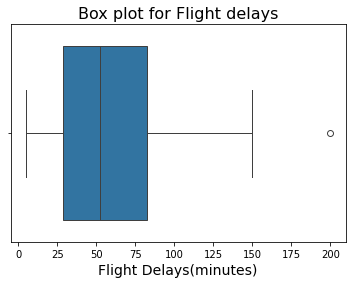

In [12]:
##To see the overall distribution in boxplot
sns.boxplot(x=data)
plt.title('Box plot for Flight delays', fontsize=16)
plt.xlabel('Flight Delays(minutes)', fontsize=14)

plt.show()


In [ ]:
'''Question 2 :
A company wants to analyze the salary distribution of its employees to understand the central tendency and determine whether the data is skewed.
DataSet:
salaries = [30000, 32000, 35000, 37000, 40000, 42000, 45000, 47000, 50000, 55000,
            60000, 62000, 65000, 67000, 70000, 72000, 75000, 80000, 85000, 90000]'''

Mean Salary: 56950.0
Median Salary: 57500.0
Mode Salary: 30000
The data is Left Skewed (Negative Skew)


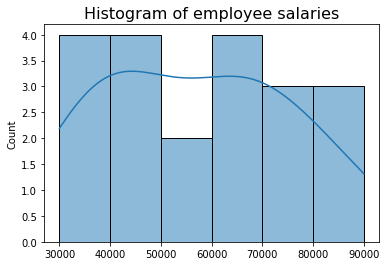

In [23]:
import numpy as np
from scipy.stats import mode
import seaborn as sns
import matplotlib.pyplot as plt

## To calculate central tendency

data = [30000, 32000, 35000, 37000, 40000, 42000, 45000, 47000, 50000, 55000,
            60000, 62000, 65000, 67000, 70000, 72000, 75000, 80000, 85000, 90000]

mean=np.mean(data)
median=np.median(data)
mode=mode(data)

print("Mean Salary:",mean)
print("Median Salary:",median)
print("Mode Salary:",mode[0][0])

if mean<median:
    print("The data is Left Skewed (Negative Skew)")
elif mean> median:
    print("The data is Right Skewed (Positive Skew)")
else:
    print("Data is not skewed")

    

sns.histplot(data, kde=True)
plt.title("Histogram of employee salaries",fontsize=16)
plt.show()


In [ ]:
'''Question 3:
 A school wants to analyze the exam performance of students across three subjects: Mathematics, Science, and English. How can Data Science concepts be applied to understand their performance?
DataSet:
data = {
    'Student': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J'],
    'Mathematics': [85, 78, 92, 88, 70, 95, 60, 80, 90, 76],
    'Science': [80, 85, 88, 70, 75, 92, 55, 82, 89, 78],
    'English': [78, 74, 85, 80, 68, 90, 50, 77, 83, 72]
}'''

Mean of Maths, Science, English: 81.4 79.4 75.7
Median of Maths, Science, English: 82.5 81.0 77.5
Mode of Maths, Science, English: 70 70 68


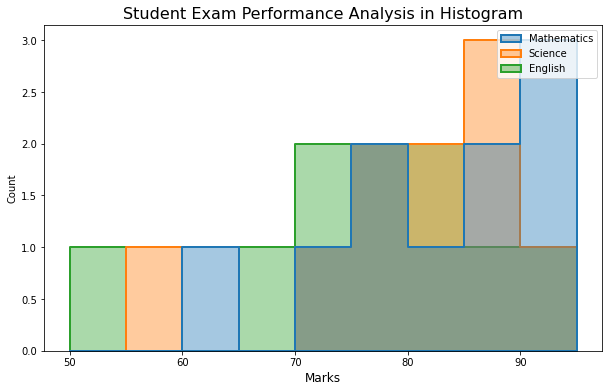

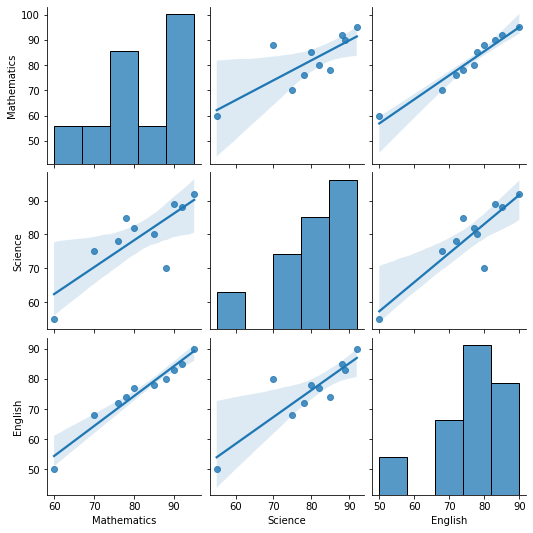

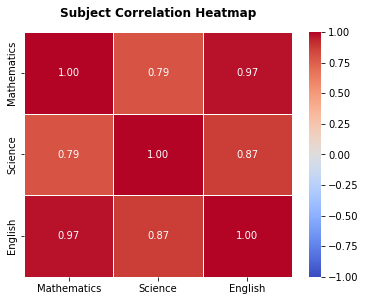

In [54]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = {
    'Student': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J'],
    'Mathematics': [85, 78, 92, 88, 70, 95, 60, 80, 90, 76],
    'Science': [80, 85, 88, 70, 75, 92, 55, 82, 89, 78],
    'English': [78, 74, 85, 80, 68, 90, 50, 77, 83, 72]}



df = pd.DataFrame(data)
df.drop(columns=['Student'],inplace=True)

#Using Central tendency, calculate mean to know the average in each subject. Based on the average, the teaching should be shifted.

mean_M=df['Mathematics'].mean()
median_M=df['Mathematics'].median()
mode_M=df['Mathematics'].mode()

mean_S=df['Science'].mean()
median_S=df['Science'].median()
mode_S=df['Science'].mode()

mean_E=df['English'].mean()
median_E=df['English'].median()
mode_E=df['English'].mode()

std_M=df['Mathematics'].std()
std_S=df['Science'].std()
std_E=df['English'].std()

print("Mean of Maths, Science, English:",mean_M,mean_S,mean_E)
print("Median of Maths, Science, English:",median_M,median_S,median_E)
print("Mode of Maths, Science, English:",mode_M[1],mode_S[1],mode_E[1])

plt.figure(figsize=(10, 6))
sns.histplot(df,    binwidth=5, 
    element="step", 
    alpha=0.4, 
    linewidth=2)
plt.title('Student Exam Performance Analysis in Histogram',fontsize=16)
plt.xlabel('Marks',fontsize=12)
plt.show()

# Correlation Analysis
'''plt.figure(figsize=(6, 4))
sns.regplot(data=df, x='Mathematics', y='English', color='g', marker='o')
plt.title("Scatter Plot: Math vs English Correlation")
plt.xlabel("Mathematics Grades")
plt.ylabel("English Grades")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()'''


# Pairplot- to create a grid of scatter plots for every subject pairing
sns.pairplot(df, kind='reg')
plt.show()


# Compute correlation matrix on numeric columns only
corr_matrix = df.corr()

# Create Heatmap
plt.figure(figsize=(6, 4.5))
sns.heatmap(
    corr_matrix, 
    annot=True,          # Show exact numbers inside the blocks
    cmap='coolwarm',     # Red for positive correlation, Blue for negative
    vmin=-1, vmax=1,     # Fix the scale boundaries
    fmt=".2f",          # Limit to 2 decimal places
    linewidths=0.5
)

plt.title("Subject Correlation Heatmap", fontsize=12, fontweight='bold', pad=15)
plt.show()



In [ ]:
'''Question 4:
A pharmaceutical company conducted a clinical trial with two groups: one receiving medication and the other a placebo. How do you perform a hypothesis test to determine the effectiveness of the medication?
Dataset:
medication_group = [110, 115, 108, 102, 107, 99, 111, 104, 109, 101]
placebo_group = [120, 125, 130, 122, 128, 119, 124, 127, 123, 126]'''

In [57]:
##Answer
medication = [110, 115, 108, 102, 107, 99, 111, 104, 109, 101]
placebo = [120, 125, 130, 122, 128, 119, 124, 127, 123, 126]

##Null Hypothesis: H0: There is no significant effect on the medication
##Alternate Hypothesis: H1: There is a significant effect on the medication

from scipy.stats import ttest_ind
static_value, p_value = ttest_ind(medication,placebo)
print(f"T-Statistic:{static_value}, p_value:{p_value}" )

if p_value <=0.05:
    print("Reject the null hypothesis: The medication is effective.")
else: 
    print("Accept the null hypothesis: The medication is not effective.")

T-Statistic:-9.201427649220967, p_value:3.1639128176008e-08
Reject the null hypothesis: The medication is effective.


In [ ]:
'''Question 5 : A company conducted a customer satisfaction survey where customers rated their experience on a scale of 1 to 10. Analyze the survey results to calculate descriptive statistics and visualize the distribution of customer satisfaction ratings.
Sample DataSet:  
ratings = [8, 9, 7, 5, 6, 10, 9, 4, 7, 8, 
           6, 9, 10, 5, 8, 7, 6, 9, 10, 7]'''

Mean Rating: 7.5
Median Rating: 7.5
Mode Rating: 7
Standard Deviation:: 1.746424919657298


Text(0.5, 0, 'Customer satisfaction ratings')

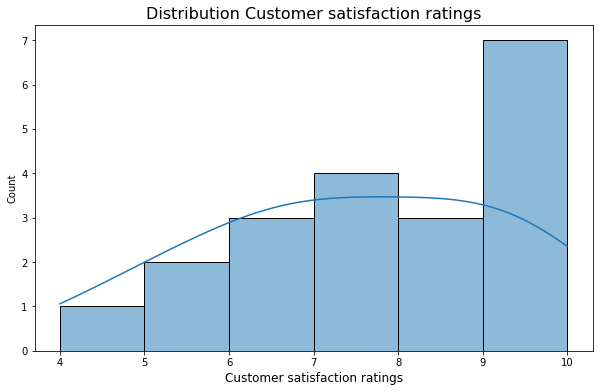

In [67]:
import numpy as np
from scipy.stats import mode
import seaborn as sns
import matplotlib.pyplot as plt

data = [8, 9, 7, 5, 6, 10, 9, 4, 7, 8, 
           6, 9, 10, 5, 8, 7, 6, 9, 10, 7]


Mean=np.mean(data)
Median=np.median(data)
Mode=mode(data)[0][0]
Std=np.std(data)
print("Mean Rating:",Mean)
print("Median Rating:",Median)
print("Mode Rating:",Mode)
print("Standard Deviation::",Std)

plt.figure(figsize=(10, 6))
plt.title("Distribution Customer satisfaction ratings", fontsize=16)
sns.histplot(data,kde=True)
plt.xlabel("Customer satisfaction ratings",fontsize=12)
